# AERO 355 - HW1
*Created by Henry Flushman*

---

### Imports

In [65]:
import math
import numpy as np
import matplotlib.pyplot as plt
import os

---
### Problem 4
**Part a: Residence Time**

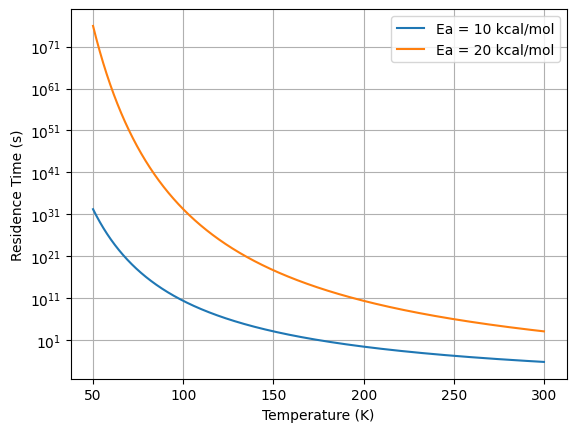

In [66]:
def ResidTime(
    activationEnergy = 0.5,
    planksConst = 6.62607015e-34,
    boltzConst = 1.380649e-23,
    tauRef = None,
    temp = 300,
    R = 8.314):
    
    if tauRef is not None:
        refTau = tauRef
    else:
        refTau = planksConst / (boltzConst * temp)
    return refTau * math.exp(activationEnergy / (R * temp))

Ea = np.array([10, 20])
T = np.arange(50, 300, .1)

for ea in Ea:
    tau = [ResidTime(temp=i, activationEnergy=ea, tauRef=3e-12, R=1.9858775e-3) for i in T]
    plt.semilogy(T, tau, label=f"Ea = {ea:.0f} kcal/mol")
    
plt.xlabel("Temperature (K)")
plt.ylabel("Residence Time (s)")
plt.legend()
plt.grid(True)
plt.show()

---
**Part b: Least Residence Time at 150K**

In [67]:
e10t150 = ResidTime(temp=150, activationEnergy=10, tauRef=3e-12, R=1.9858775e-3)
e20t150 = ResidTime(temp=150, activationEnergy=20, tauRef=3e-12, R=1.9858775e-3)
if e10t150 < e20t150:
    print(f"At 150 K, the residence time for Ea = 10 kcal/mol is shorter than that for Ea = 20 kcal/mol.")
else:
    print(f"At 150 K, the residence time for Ea = 20 kcal/mol is shorter than that for Ea = 10 kcal/mol.")

At 150 K, the residence time for Ea = 10 kcal/mol is shorter than that for Ea = 20 kcal/mol.


---
**Part c: 150K Residence Time Value**

In [68]:
print(f"Residence time for Ea = 10 kcal/mol at 150 K: {e10t150:.0f} s")

Residence time for Ea = 10 kcal/mol at 150 K: 1139 s


---
### Problem 5
**Part a: Daily Mass Loss**

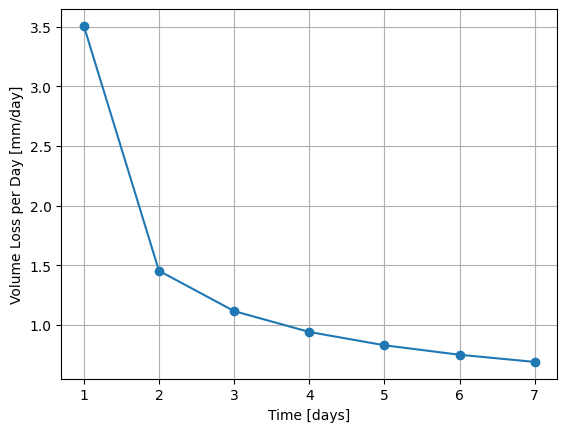

In [200]:
# Constants
R = 1.9858775e-3    # kcal/(mol*K)

# Initial values
initialMass = 5     # grams
TML = 0.0025
T = 100 + 273.15    # Kelvin
Ea = 15             # kcal/mol


finalMass = initialMass - TML * initialMass

q0 = (initialMass - finalMass) / ((2*np.exp(-Ea/(R*(125+273.15)))*(np.sqrt(24*3600))))

def DeltaMassPerDay(day):
    t2 = day*24*3600
    t1 = (day-1)*24*3600
    return 2*q0*np.exp(-Ea/(R*T))*(np.sqrt(t2)-np.sqrt(t1))

time = np.arange(1, 8, 1)
dm = [DeltaMassPerDay(t) for t in time]
plt.plot(time, np.array(dm)*1000, 'o-')
plt.xlabel("Time [days]")
plt.ylabel("Volume Loss per Day [mm/day]")
plt.grid(True)
plt.show()


---
**Part b: Mass Loss for Day 2**

In [201]:
print(f"The amount of mass lost on day 2 at 100 C is approximately {DeltaMassPerDay(2):.4f} grams")

The amount of mass lost on day 2 at 100 C is approximately 0.0015 grams


---
**Part c: Daily Arrival Rate vs Time**

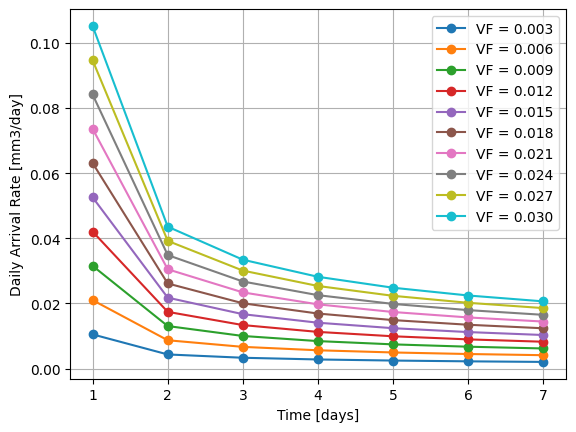

In [202]:
def DeltaVArrival(day, viewFactor):
    return viewFactor*DeltaMassPerDay(day)

viewFactor = np.arange(0.003, 0.031, 0.003)
days = np.arange(1, 8, 1)

for vf in viewFactor:
    massArrival = [DeltaVArrival(t, vf) for t in days]
    plt.plot(days, np.array(massArrival)*1000, 'o-', label=f"VF = {vf:.3f}")
    
plt.xlabel("Time [days]")
plt.ylabel("Daily Arrival Rate [mm3/day]")
plt.legend()
plt.grid(True)
plt.show()

---
**Part d: Arrival Rate for Day 7**
\
*Given*
*VF = 0.03*

In [204]:
rateArrivalD7_mm3PerHour = DeltaVArrival(7, 0.03) * 1000 / 24

print(f"The arrival rate for the 7th day given a view factor of 0.03 is:\n\n {rateArrivalD7_mm3PerHour:.4f} mm^3/hr")

The arrival rate for the 7th day given a view factor of 0.03 is:

 0.0009 mm^3/hr


---
### Problem 6
**Part a: Time Elapsed for Natural De-Orbit**

In [205]:
# Constants
g = 9.81    # m/s2
R = 8.314   # J/(mol*K)

# Given
k = 1.38e-23                # J/K
massDensity = 1.2023e-13    # kg/m3
satMass = 1                 # kg
scaleHeight = 124000        # m
crossSection = 100e-4       # m2
altInitial = 800000         # m
muEarth = 3.968e14          # m3/s2
dragCoef = 2.2

# Analysis

rInitial = 6.378e6 + altInitial
semiMajorAxis = rInitial

dadt = -(massDensity*dragCoef*crossSection*np.sqrt(muEarth*semiMajorAxis))/satMass

L = 124000/abs(dadt)
print(f"The estimated lifetime of the satellite in days is approximately: \n\n {L/(24*3600):.0f} days")


The estimated lifetime of the satellite in days is approximately: 

 10167 days


---
**Part b: Time to De-Orbit vs Drag Sail Size**

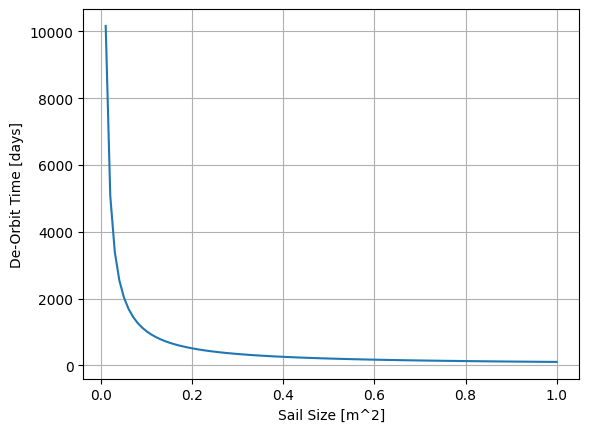

In [206]:
def dadt(sailSize):
    return -(massDensity*dragCoef*sailSize*np.sqrt(muEarth*semiMajorAxis))/satMass

sailSize = np.arange(0.01, 1.01, 0.01)
deOrbitSeconds = 124000/abs(dadt(sailSize))

plt.plot(sailSize, deOrbitSeconds/(24*3600))
plt.xlabel("Sail Size [m^2]")
plt.ylabel("De-Orbit Time [days]")
plt.grid(True)

---
**Part c: Lifetime for $1m^2$ Solar Sail**

In [207]:
print(f"The lifetime of a 1m^2 sail given these conditions, is approximately: \n\n{deOrbitSeconds[-1]/(24*3600):.0f} days")

The lifetime of a 1m^2 sail given these conditions, is approximately: 

102 days


---
**Part d: Analysis of De-Orbit Plot**

In [208]:
print("L is proportional to 1/sailSize, so the plot should follow a hyperbolic trend, which the plot above shows. It is also expected that the 0.01 m^2 sail takes 100x longer than the sail thats 100x as big as no other variable is changed.")

L is proportional to 1/sailSize, so the plot should follow a hyperbolic trend, which the plot above shows. It is also expected that the 0.01 m^2 sail takes 100x longer than the sail thats 100x as big as no other variable is changed.


---
### Question 7
**Part a: Erosion Depth per Day vs Time**

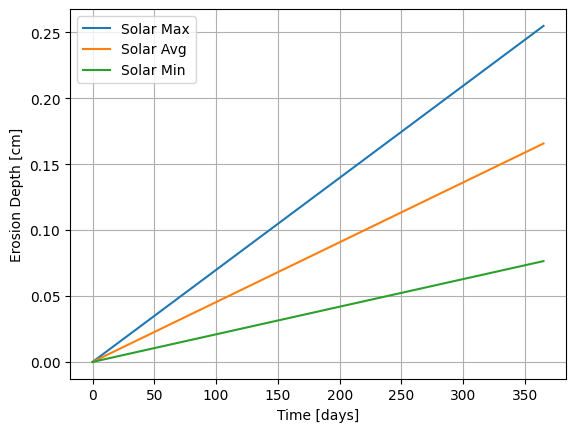

In [209]:
# Initial Values
altInitial = 320000       # m
rInitial = 6.378e6 + altInitial
semiMajorAxis = rInitial
nMin = 3e14             # m^-3
nMax = 1e15             # m^-3
nAvg = (nMin + nMax) / 2
E = 10.5e-24            # cm3/atom

# Opening the AODensity file
with open("AOdensity.txt", "r") as f:
    aoDensity = f.read()

# Analysis
def ErosionRate(n):
    fluence = n*V/1e4
    return E*fluence    # cm/s

V = np.sqrt(muEarth/rInitial)   # m/s

days = np.arange(0, 366, 1)
t = days*24*3600

depthMin = ErosionRate(nMin)*t
depthMax = ErosionRate(nMax)*t
depthAvg = ErosionRate(nAvg)*t

plt.plot(days, depthMax, label='Solar Max')
plt.plot(days, depthAvg, label='Solar Avg')
plt.plot(days, depthMin, label='Solar Min')

plt.xlabel("Time [days]")
plt.ylabel("Erosion Depth [cm]")
plt.legend()
plt.grid(True)

---
**Part b: Erosion Depth at 1 Year for Solar Max**

In [210]:
print(f"The erosion depth after 1 year at solar max conditions is approximately: \n\n {depthMax[-1]:.2f} cm")

The erosion depth after 1 year at solar max conditions is approximately: 

 0.25 cm


---
**Part c: Time Until Mission Failure**

In [211]:
# Initial Values
diameter = 0.04   # cm
time2Radius = (diameter/2) / (ErosionRate(nMax))    # s

print(f"The time it takes for the AO to erode through the entire diameter of the interconnect is approximately: \n\n{time2Radius/(24*3600):.0f} days")

The time it takes for the AO to erode through the entire diameter of the interconnect is approximately: 

29 days
